In [1]:
# ── Cell 1: Mount Drive & Imports ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from scipy.optimize import minimize

print("Libraries loaded.")

Mounted at /content/drive
Libraries loaded.


In [2]:
# ── Cell 2: Paths ─────────────────────────────────────────────────────────────
RESULTS_DIR  = "/content/drive/MyDrive/disaster_project/disagreement_analysis"
ENSEMBLE_DIR = "/content/drive/MyDrive/disaster_project/ensemble_results"
DATA_DIR     = "/content/drive/MyDrive/disaster_project/disaster_data"
os.makedirs(ENSEMBLE_DIR, exist_ok=True)

MODEL_NAMES = ["RoBERTa", "DeBERTa", "ELECTRA"]


In [3]:
# ── Cell 3: Load Label Mapping ────────────────────────────────────────────────
with open(f"{DATA_DIR}/label_mapping.json") as f:
    mapping = json.load(f)

label2id   = mapping["label2id"]
id2label   = {int(k): v for k, v in mapping["id2label"].items()}
NUM_LABELS = len(label2id)
CLASS_NAMES = [id2label[i] for i in range(NUM_LABELS)]

SHORT_NAMES = [
    "caution", "displaced", "infrastructure", "injured", "missing",
    "not_humanitarian", "other", "requests", "rescue", "sympathy"
]

print(f"Labels loaded: {NUM_LABELS} classes")


Labels loaded: 10 classes


In [4]:
# ── Cell 4: Load Saved Predictions ────────────────────────────────────────────
predictions = {}

for name in MODEL_NAMES:
    path = f"{RESULTS_DIR}/{name.lower()}_predictions.npz"
    data = np.load(path)
    predictions[name] = {
        "preds":  data["preds"],
        "labels": data["labels"],
        "probs":  data["probs"],
    }
    acc = (data["preds"] == data["labels"]).mean()
    f1  = f1_score(data["labels"], data["preds"], average="macro")
    print(f"  {name}: loaded {len(data['preds'])} samples | Accuracy={acc:.3f} | Macro F1={f1:.4f}")

true_labels = predictions["RoBERTa"]["labels"]  # same for all models


  RoBERTa: loaded 15160 samples | Accuracy=0.783 | Macro F1=0.7604
  DeBERTa: loaded 15160 samples | Accuracy=0.782 | Macro F1=0.7600
  ELECTRA: loaded 15160 samples | Accuracy=0.778 | Macro F1=0.7553


In [5]:
# ── Cell 5: Compute Per-Class F1 for Each Model ───────────────────────────────
# This is the foundation of complementarity weighting —
# each model's per-class F1 tells us where it is strong vs weak

per_class_f1 = {}

print("\nPer-Class F1 Scores:")
print(f"{'Class':<45} {'RoBERTa':>8} {'DeBERTa':>8} {'ELECTRA':>8}")
print("-" * 75)

for name in MODEL_NAMES:
    f1_scores = f1_score(
        predictions[name]["labels"],
        predictions[name]["preds"],
        average=None,
        labels=list(range(NUM_LABELS))
    )
    per_class_f1[name] = f1_scores

for c in range(NUM_LABELS):
    scores = [per_class_f1[name][c] for name in MODEL_NAMES]
    print(f"  {CLASS_NAMES[c]:<43} {scores[0]:>8.4f} {scores[1]:>8.4f} {scores[2]:>8.4f}")



Per-Class F1 Scores:
Class                                          RoBERTa  DeBERTa  ELECTRA
---------------------------------------------------------------------------
  caution_and_advice                            0.7069   0.7067   0.7015
  displaced_people_and_evacuations              0.8910   0.8861   0.8894
  infrastructure_and_utility_damage             0.8141   0.8147   0.8128
  injured_or_dead_people                        0.9285   0.9277   0.9255
  missing_or_found_people                       0.7770   0.7770   0.7681
  not_humanitarian                              0.6192   0.6198   0.5964
  other_relevant_information                    0.5410   0.5543   0.5344
  requests_or_urgent_needs                      0.6026   0.6046   0.6075
  rescue_volunteering_or_donation_effort        0.8805   0.8766   0.8742
  sympathy_and_support                          0.8433   0.8321   0.8426


In [6]:
# ── Cell 6: Complementarity Weight Computation ────────────────────────────────
# For each class, assign weight to each model proportional to:
# (1) its F1 on that class
# (2) how different its errors are from other models (complementarity bonus)
#
# Complementarity bonus: if a model's per-class F1 is high where others are low,
# it gets a higher weight for that class

print("\n--- Computing Complementarity Weights ---")

# Step 1: Build per-class weight matrix [num_models x num_classes]
# Base weight = per-class F1, normalised across models per class
f1_matrix = np.array([per_class_f1[name] for name in MODEL_NAMES])  # [3 x 10]

# Step 2: Compute complementarity bonus
# For each model m and class c:
# bonus(m,c) = how much better model m is vs the average of the other models on class c
avg_others = np.zeros_like(f1_matrix)
for i in range(len(MODEL_NAMES)):
    others = [j for j in range(len(MODEL_NAMES)) if j != i]
    avg_others[i] = f1_matrix[others].mean(axis=0)

complementarity_bonus = f1_matrix - avg_others  # positive = better than others on this class

# Step 3: Final per-class weight = F1 + alpha * complementarity_bonus
# alpha controls how much we reward uniqueness vs raw performance
alpha = 0.5
raw_weights = f1_matrix + alpha * np.clip(complementarity_bonus, 0, None)

# Step 4: Normalise weights per class so they sum to 1
weight_matrix = raw_weights / raw_weights.sum(axis=0, keepdims=True)  # [3 x 10]

print("\nPer-Class Complementarity Weights:")
print(f"{'Class':<45} {'RoBERTa':>8} {'DeBERTa':>8} {'ELECTRA':>8}")
print("-" * 75)
for c in range(NUM_LABELS):
    w = weight_matrix[:, c]
    print(f"  {CLASS_NAMES[c]:<43} {w[0]:>8.4f} {w[1]:>8.4f} {w[2]:>8.4f}")



--- Computing Complementarity Weights ---

Per-Class Complementarity Weights:
Class                                          RoBERTa  DeBERTa  ELECTRA
---------------------------------------------------------------------------
  caution_and_advice                            0.3344   0.3343   0.3313
  displaced_people_and_evacuations              0.3345   0.3321   0.3335
  infrastructure_and_utility_damage             0.3334   0.3338   0.3328
  injured_or_dead_people                        0.3340   0.3335   0.3325
  missing_or_found_people                       0.3349   0.3349   0.3302
  not_humanitarian                              0.3383   0.3388   0.3229
  other_relevant_information                    0.3303   0.3435   0.3262
  requests_or_urgent_needs                      0.3317   0.3328   0.3355
  rescue_volunteering_or_donation_effort        0.3353   0.3328   0.3319
  sympathy_and_support                          0.3354   0.3298   0.3349


In [7]:
# ── Cell 7: Ensemble Inference ────────────────────────────────────────────────
# For each sample, combine softmax probabilities using per-class weights
# Weight each model's probability vector by its weight for the predicted class

print("\n--- Running Ensemble Inference ---")

# Stack probability arrays: [3 x N x 10]
probs_stack = np.array([predictions[name]["probs"] for name in MODEL_NAMES])
N = probs_stack.shape[1]

# Weighted combination:
# For each class c, ensemble_prob[:, c] = sum over models of weight[model, c] * prob[model, :, c]
ensemble_probs = np.zeros((N, NUM_LABELS))

for c in range(NUM_LABELS):
    for i, name in enumerate(MODEL_NAMES):
        ensemble_probs[:, c] += weight_matrix[i, c] * probs_stack[i, :, c]

ensemble_preds = np.argmax(ensemble_probs, axis=1)



--- Running Ensemble Inference ---


In [8]:
# ── Cell 8: Evaluate Ensemble ─────────────────────────────────────────────────
ensemble_f1  = f1_score(true_labels, ensemble_preds, average="macro")
ensemble_acc = (ensemble_preds == true_labels).mean()

print(f"\nEnsemble Results:")
print(f"  Macro F1 : {ensemble_f1:.4f}")
print(f"  Accuracy : {ensemble_acc:.4f}")

print("\n--- Individual Model Results (for comparison) ---")
for name in MODEL_NAMES:
    f1  = f1_score(predictions[name]["labels"], predictions[name]["preds"], average="macro")
    acc = (predictions[name]["preds"] == predictions[name]["labels"]).mean()
    print(f"  {name:<10}: Macro F1={f1:.4f} | Accuracy={acc:.4f}")

print("\nClassification Report — Ensemble:")
print(classification_report(true_labels, ensemble_preds, target_names=CLASS_NAMES))



Ensemble Results:
  Macro F1 : 0.7690
  Accuracy : 0.7909

--- Individual Model Results (for comparison) ---
  RoBERTa   : Macro F1=0.7604 | Accuracy=0.7832
  DeBERTa   : Macro F1=0.7600 | Accuracy=0.7817
  ELECTRA   : Macro F1=0.7553 | Accuracy=0.7782

Classification Report — Ensemble:
                                        precision    recall  f1-score   support

                    caution_and_advice       0.67      0.76      0.72      1070
      displaced_people_and_evacuations       0.88      0.91      0.90       790
     infrastructure_and_utility_damage       0.78      0.87      0.82      1617
                injured_or_dead_people       0.91      0.95      0.93      1447
               missing_or_found_people       0.85      0.72      0.78        72
                      not_humanitarian       0.68      0.59      0.63      1245
            other_relevant_information       0.64      0.50      0.56      2407
              requests_or_urgent_needs       0.64      0.61      0.62 

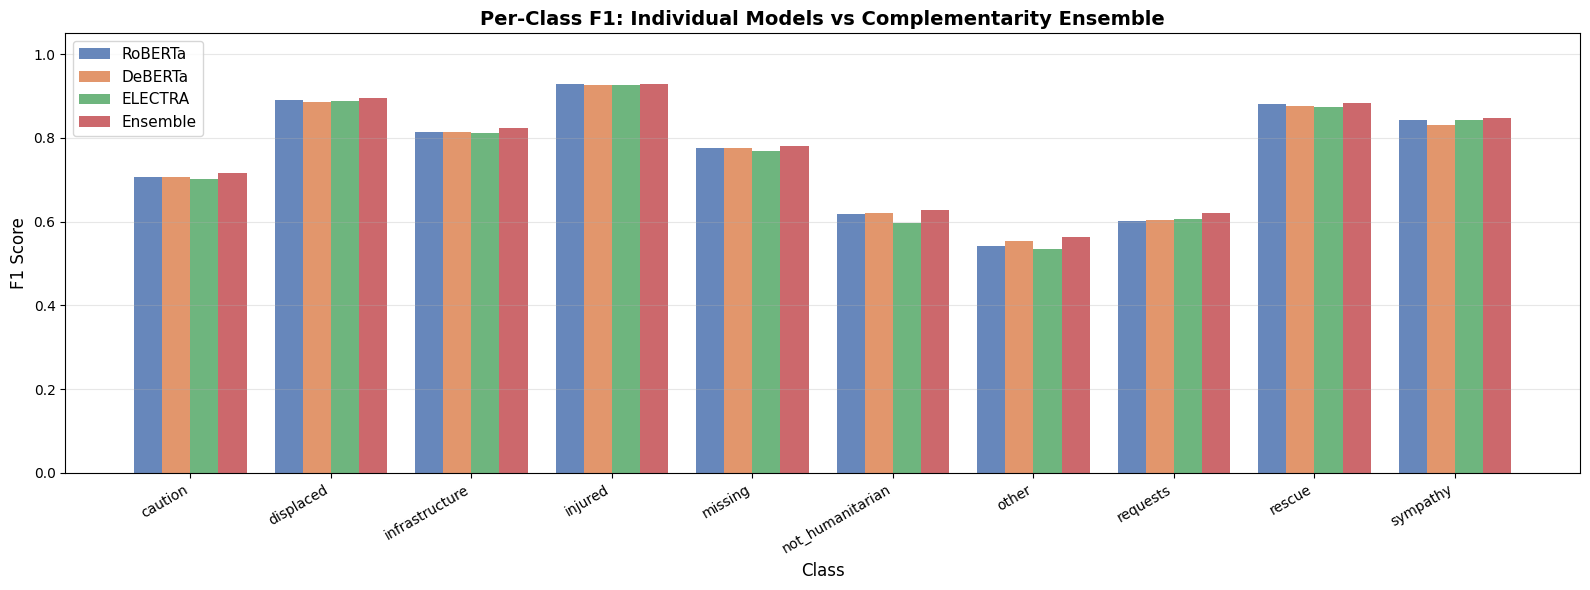

✅ Per-class F1 comparison plot saved.


In [9]:
# ── Cell 9: Per-Class F1 Comparison Plot ──────────────────────────────────────
ensemble_per_class_f1 = f1_score(
    true_labels, ensemble_preds,
    average=None, labels=list(range(NUM_LABELS))
)

x       = np.arange(NUM_LABELS)
width   = 0.2
colors  = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(16, 6))

for i, (name, color) in enumerate(zip(MODEL_NAMES + ["Ensemble"], colors)):
    if name == "Ensemble":
        f1_vals = ensemble_per_class_f1
    else:
        f1_vals = per_class_f1[name]
    bars = ax.bar(x + i * width, f1_vals, width, label=name, color=color, alpha=0.85)

ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Per-Class F1: Individual Models vs Complementarity Ensemble", fontsize=14, fontweight="bold")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(SHORT_NAMES, rotation=30, ha="right", fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{ENSEMBLE_DIR}/per_class_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Per-class F1 comparison plot saved.")

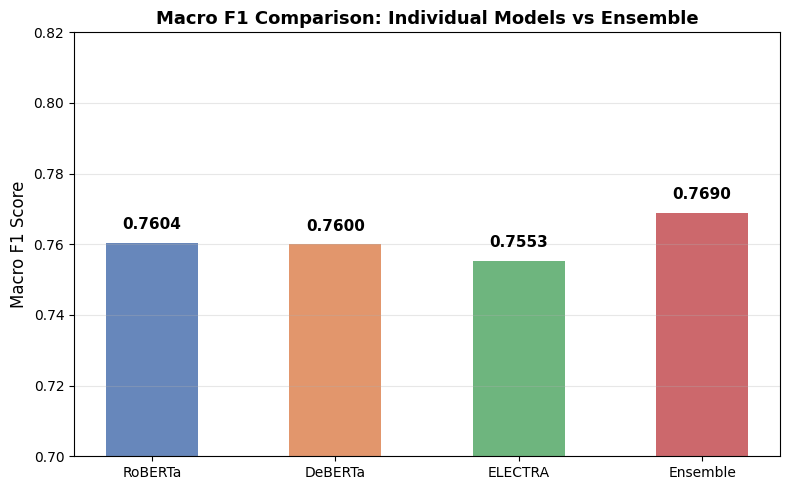

✅ Macro F1 comparison chart saved.


In [10]:
# ── Cell 10: Overall F1 Summary Bar Chart ─────────────────────────────────────
all_names  = MODEL_NAMES + ["Ensemble"]
all_f1s    = [f1_score(predictions[n]["labels"], predictions[n]["preds"], average="macro")
              for n in MODEL_NAMES] + [ensemble_f1]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(all_names, all_f1s, color=colors, alpha=0.85, width=0.5)

for bar, val in zip(bars, all_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("Macro F1 Score", fontsize=12)
ax.set_title("Macro F1 Comparison: Individual Models vs Ensemble", fontsize=13, fontweight="bold")
ax.set_ylim(0.70, 0.82)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{ENSEMBLE_DIR}/macro_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Macro F1 comparison chart saved.")


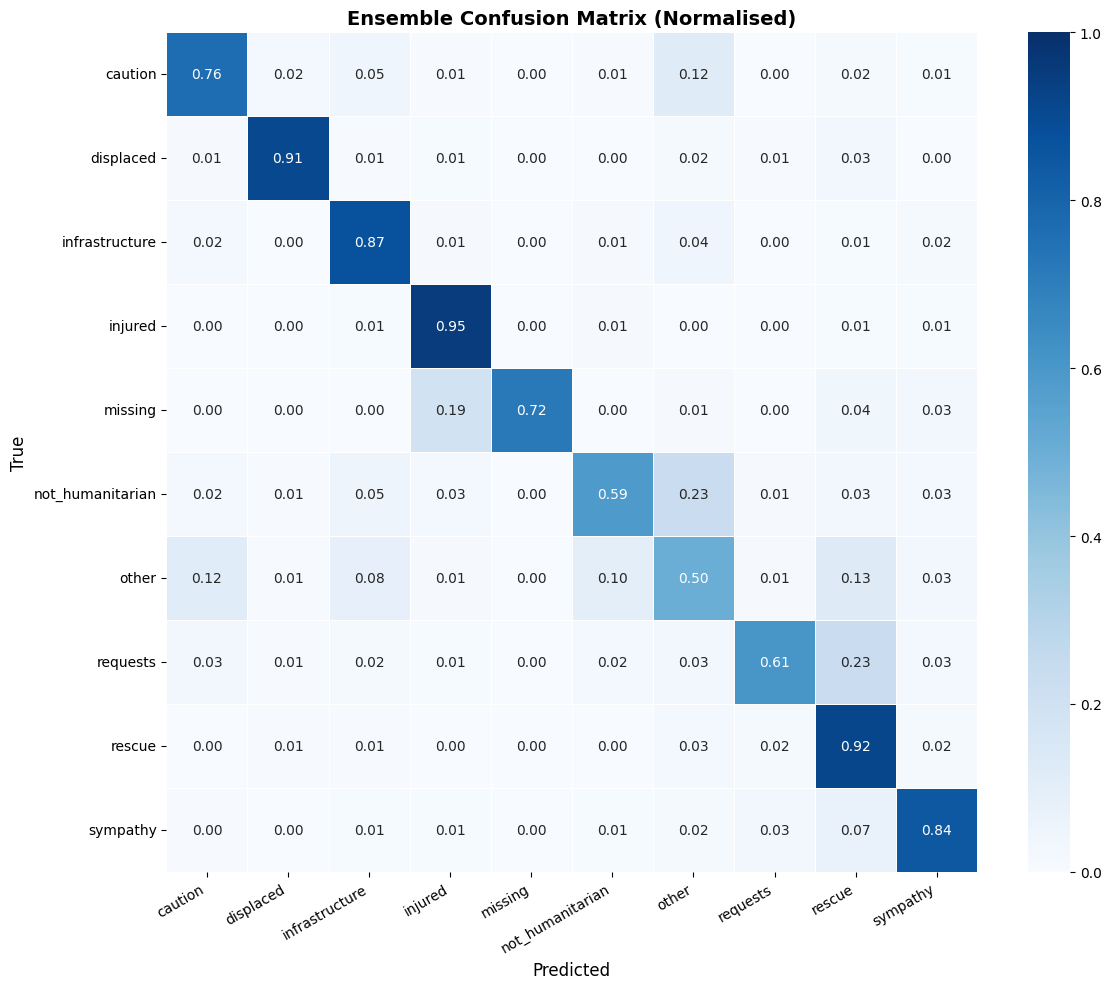

✅ Confusion matrix saved.


In [11]:
# ── Cell 11: Confusion Matrix — Ensemble ─────────────────────────────────────
cm = confusion_matrix(true_labels, ensemble_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
    linewidths=0.5, ax=ax, vmin=0, vmax=1
)
ax.set_title("Ensemble Confusion Matrix (Normalised)", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{ENSEMBLE_DIR}/ensemble_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix saved.")

In [12]:
# ── Cell 12: Save Ensemble Results ────────────────────────────────────────────
# Save ensemble predictions and weights for use in confidence + explainability scripts
np.savez(
    f"{ENSEMBLE_DIR}/ensemble_predictions.npz",
    preds=ensemble_preds,
    labels=true_labels,
    probs=ensemble_probs,
)

np.save(f"{ENSEMBLE_DIR}/weight_matrix.npy", weight_matrix)

summary = {
    "ensemble_macro_f1":  float(f"{ensemble_f1:.4f}"),
    "ensemble_accuracy":  float(f"{ensemble_acc:.4f}"),
    "individual_results": {
        name: {
            "macro_f1": float(f"{f1_score(predictions[name]['labels'], predictions[name]['preds'], average='macro'):.4f}"),
            "accuracy": float(f"{(predictions[name]['preds'] == predictions[name]['labels']).mean():.4f}"),
        }
        for name in MODEL_NAMES
    },
    "weight_matrix": {
        MODEL_NAMES[i]: {
            CLASS_NAMES[c]: float(f"{weight_matrix[i, c]:.4f}")
            for c in range(NUM_LABELS)
        }
        for i in range(len(MODEL_NAMES))
    }
}

with open(f"{ENSEMBLE_DIR}/ensemble_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print(f"\n✅ All ensemble outputs saved to {ENSEMBLE_DIR}")
print("\n" + "="*55)
print("ENSEMBLE COMPLETE")
print("="*55)
print(f"  Best individual model (RoBERTa): {max(all_f1s[:-1]):.4f}")
print(f"  Ensemble Macro F1:               {ensemble_f1:.4f}")
print(f"  Improvement:                    +{(ensemble_f1 - max(all_f1s[:-1]))*100:.2f} F1 points")
print("="*55)
print("\nNext step: Novelty 2 — Adaptive Confidence-Based Selective Prediction")


✅ All ensemble outputs saved to /content/drive/MyDrive/disaster_project/ensemble_results

ENSEMBLE COMPLETE
  Best individual model (RoBERTa): 0.7604
  Ensemble Macro F1:               0.7690
  Improvement:                    +0.86 F1 points

Next step: Novelty 2 — Adaptive Confidence-Based Selective Prediction
